# Hybrid ResGNN-UNet for Next-Day Wildfire Spread Prediction

This notebook implements a hybrid architecture combining:
- **Residual CNN Encoder** for spatial feature extraction
- **Graph Attention Network (GAT)** bottleneck for fire propagation modeling  
- **U-Net Decoder** with skip connections for pixel-level prediction

**Dataset:** Next Day Wildfire Spread (NDWS) - 18,445 samples, 64×64 tiles, 12 input channels

**Run all cells in order for proper train/val/test evaluation.**

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.8.0+cu126
CUDA version: 12.6


In [3]:
# Install PyTorch Geometric dependencies for PyTorch 2.6.0 + CUDA 12.4
!pip install protobuf==3.20.3
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have proto

In [4]:
# Install PyTorch Geometric and dependencies
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
import matplotlib.pyplot as plt

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  import torch_geometric.typing
/usr/

Using device: cuda


In [5]:
import tensorflow as tf
import numpy as np
import os
import glob

# --- Setup Paths ---
INPUT_DIR = '/kaggle/input/next-day-wildfire-spread'
OUTPUT_DIR = '/kaggle/working/processed_data'

MAX_SAMPLES = None

# Create directories
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

IMG_SHAPE = [64, 64]

features_dict = {
    'elevation': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'th': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'vs': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'tmmn': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'tmmx': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'sph': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'pr': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'pdsi': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'NDVI': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'erc': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'population': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'PrevFireMask': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'FireMask': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32)
}

def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, features_dict)

    inputs = tf.stack([
        parsed['elevation'], parsed['th'], parsed['vs'],
        parsed['tmmn'], parsed['tmmx'], parsed['sph'],
        parsed['pr'], parsed['pdsi'], parsed['NDVI'],
        parsed['erc'], parsed['population'], parsed['PrevFireMask']
    ], axis=0)

    target = tf.expand_dims(parsed['FireMask'], axis=0)

    return tf.concat([inputs, target], axis=0)

# --- Split files based on name ---
all_files = glob.glob(os.path.join(INPUT_DIR, '*.tfrecord'))

train_files = sorted([f for f in all_files if 'train' in f])
val_files   = sorted([f for f in all_files if 'eval' in f])
test_files  = sorted([f for f in all_files if 'test' in f])

print(f"Train files: {len(train_files)}")
print(f"Val files:   {len(val_files)}")
print(f"Test files:  {len(test_files)}")

def process_split(file_list, split_name):
    dataset = tf.data.TFRecordDataset(file_list)
    dataset = dataset.map(parse_tfrecord)

    count = 0
    for i, data in enumerate(dataset):
        if MAX_SAMPLES is not None and i >= MAX_SAMPLES:
            break
        
        np.save(
            os.path.join(OUTPUT_DIR, split_name, f'sample_{i}.npy'),
            data.numpy()
        )
        count += 1

    print(f"{split_name}: {count} samples saved")

# --- Process each split ---
process_split(train_files, 'train')
process_split(val_files, 'val')
process_split(test_files, 'test')

print("\n=== DONE: Correct Dataset Split ===")

2026-04-12 16:11:23.052684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776010283.209117      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776010283.253412      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776010283.611603      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776010283.611640      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776010283.611643      55 computation_placer.cc:177] computation placer alr

Train files: 15
Val files:   2
Test files:  2


I0000 00:00:1776010295.194551      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776010295.200585      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train: 14979 samples saved
val: 1877 samples saved
test: 1689 samples saved

=== DONE: Correct Dataset Split ===


In [6]:
# ============================================
# FIXED DATASET CLASS WITH PROPER SPLITS
# ============================================

class WildfireDataset(Dataset):
    def __init__(self, data_dir, split='train'):
        split_dir = os.path.join(data_dir, split)
        self.files = sorted([os.path.join(split_dir, f) for f in os.listdir(split_dir) if f.endswith('.npy')])
        print(f"Loaded {len(self.files)} samples for {split} split")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        x = torch.tensor(data[:-1, :, :], dtype=torch.float32)
        y = torch.tensor(data[-1:, :, :], dtype=torch.float32)
        
        # Z-score normalization per sample
        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True)
        x = (x - mean) / (std + 1e-6)
        
        return x, y

# --- Initialize All DataLoaders ---
DATA_DIR = '/kaggle/working/processed_data'

train_dataset = WildfireDataset(DATA_DIR, split='train')
val_dataset = WildfireDataset(DATA_DIR, split='val')
test_dataset = WildfireDataset(DATA_DIR, split='test')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\nDataLoaders ready:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

Loaded 14979 samples for train split
Loaded 1877 samples for val split
Loaded 1689 samples for test split

DataLoaders ready:
  Train batches: 469
  Val batches:   59
  Test batches:  53


In [7]:
# ============================================
# TOPOLOGY GENERATOR (Grid to Graph)
# ============================================

def get_grid_topology(H, W, device):
    """
    Generates edge_index for an 8-connected grid of size HxW.
    Each pixel connects to its 8 neighbors (including diagonals).
    Returns tensor of shape [2, Num_Edges].
    """
    src_nodes = []
    dst_nodes = []

    # Offsets for 8 neighbors (including diagonals)
    offsets = [(-1, -1), (-1, 0), (-1, 1),
               ( 0, -1),          ( 0, 1),
               ( 1, -1), ( 1, 0), ( 1, 1)]

    for r in range(H):
        for c in range(W):
            curr_node = r * W + c
            for dr, dc in offsets:
                nr, nc = r + dr, c + dc
                if 0 <= nr < H and 0 <= nc < W:
                    neighbor_node = nr * W + nc
                    src_nodes.append(curr_node)
                    dst_nodes.append(neighbor_node)

    return torch.tensor([src_nodes, dst_nodes], dtype=torch.long, device=device)

print("Topology generator defined.")

Topology generator defined.


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

# --- Squeeze-Excitation Block ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(x)

# --- Residual Conv Block ---
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c)
        )
        self.skip = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(self.conv(x) + self.skip(x))


class HybridFireGNN(nn.Module):
    def __init__(self, in_channels=12, hidden_dim=96, dropout=0.35):
        super().__init__()
        self.dropout = dropout

        # --- Encoder (DEEPER + RESIDUAL + SE) ---
        self.enc1 = nn.Sequential(
            ResBlock(in_channels, 48),
            SEBlock(48),
            nn.MaxPool2d(2)
        )
        self.enc2 = nn.Sequential(
            ResBlock(48, 96),
            SEBlock(96),
            nn.MaxPool2d(2)
        )
        self.enc3 = nn.Sequential(
            ResBlock(96, hidden_dim),
            SEBlock(hidden_dim),
            nn.MaxPool2d(2)
        )

        # --- Multi-scale context ---
        self.dilated = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=2, dilation=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=4, dilation=4),
            nn.ReLU()
        )

        # --- DEEP GAT (5 layers + residual + dropout) ---
        self.gats = nn.ModuleList([
            GATConv(hidden_dim, hidden_dim, heads=4, concat=False, dropout=dropout)
            for _ in range(5)
        ])

        # --- Decoder ---
        self.up1 = nn.ConvTranspose2d(hidden_dim, 96, 2, 2)
        self.conv_up1 = nn.Sequential(
            ResBlock(96 + 96, 96),
            nn.Dropout2d(dropout)
        )

        self.up2 = nn.ConvTranspose2d(96, 48, 2, 2)
        self.conv_up2 = nn.Sequential(
            ResBlock(48 + 48, 48),
            nn.Dropout2d(dropout)
        )

        self.up3 = nn.ConvTranspose2d(48, 32, 2, 2)

        self.final = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 1)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # --- Encoder ---
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        # --- Multi-scale context ---
        e3 = e3 + self.dilated(e3)

        # --- Grid → Graph ---
        B, C_lat, H_lat, W_lat = e3.shape
        x_flat = e3.permute(0, 2, 3, 1).reshape(B * H_lat * W_lat, C_lat)

        single_edges = get_grid_topology(H_lat, W_lat, x.device)
        edge_indices = [single_edges + i * (H_lat * W_lat) for i in range(B)]
        batched_edges = torch.cat(edge_indices, dim=1)

        # --- Deep GAT with residual stacking ---
        g = x_flat
        for gat in self.gats:
            g = F.elu(gat(g, batched_edges)) + g

        # --- Graph → Grid ---
        x_gnn = g.reshape(B, H_lat, W_lat, C_lat).permute(0, 3, 1, 2)

        # --- Decoder ---
        d1 = self.conv_up1(torch.cat([self.up1(x_gnn), e2], dim=1))
        d2 = self.conv_up2(torch.cat([self.up2(d1), e1], dim=1))
        out = self.final(self.up3(d2))

        return out

In [9]:
model = HybridFireGNN(in_channels=12, hidden_dim=96, dropout=0.35).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,                 # higher peak LR
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

NUM_EPOCHS = 150  # shorter but stronger training

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.15,
    anneal_strategy='cos'
)

In [10]:
class FireLoss(nn.Module):
    def __init__(self, pos_weight=10.0, alpha=0.75, gamma=2.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        # BCE
        bce = self.bce(logits, targets)

        # Dice
        smooth = 1e-6
        intersection = (probs * targets).sum()
        dice = 1 - (2 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)

        # Focal (focus hard pixels)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal = (-self.alpha * (1 - pt) ** self.gamma * torch.log(pt + 1e-6)).mean()

        return bce + dice + focal

criterion = FireLoss(pos_weight=10.0)

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from sklearn.metrics import average_precision_score

# =============================
# LOSS FUNCTION
# =============================
class FireLoss(nn.Module):
    def __init__(self, pos_weight=10.0, alpha=0.75, gamma=2.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        # BCE
        bce = self.bce(logits, targets)

        # Dice
        smooth = 1e-6
        intersection = (probs * targets).sum()
        dice = 1 - (2 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)

        # Focal
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal = (-self.alpha * (1 - pt) ** self.gamma * torch.log(pt + 1e-6)).mean()

        return bce + dice + focal


# =============================
# METRICS
# =============================
def compute_metrics(logits, targets):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    tp = (preds * targets).sum()
    fp = (preds * (1 - targets)).sum()
    fn = ((1 - preds) * targets).sum()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    acc = (preds == targets).float().mean()

    return precision.item(), recall.item(), acc.item()


# =============================
# SETUP
# =============================
model = HybridFireGNN(in_channels=12, hidden_dim=96, dropout=0.35).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

NUM_EPOCHS = 150

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.15,
    anneal_strategy='cos'
)

criterion = FireLoss(pos_weight=10.0)

scaler = GradScaler()

best_auprc = 0.0
patience = 25
patience_counter = 0

train_losses, val_losses = [], []

print("="*60)
print(" 🔥 FINAL HARD TRAINING PIPELINE")
print(" - OneCycleLR")
print(" - AMP (Mixed Precision)")
print(" - BCE + Dice + Focal Loss")
print(" - AUPRC-based checkpointing")
print("="*60)


# =============================
# TRAIN LOOP
# =============================
for epoch in range(NUM_EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        y = (y > 0).float()

        optimizer.zero_grad()

        with autocast():
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    precision_total, recall_total, acc_total = 0, 0, 0
    all_probs, all_targets = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            y = (y > 0).float()

            logits = model(x)
            loss = criterion(logits, y)

            probs = torch.sigmoid(logits)

            p, r, a = compute_metrics(logits, y)

            precision_total += p
            recall_total += r
            acc_total += a
            val_loss += loss.item()

            all_probs.append(probs.detach().cpu().view(-1))
            all_targets.append(y.detach().cpu().view(-1))

    val_loss /= len(val_loader)
    precision = precision_total / len(val_loader)
    recall = recall_total / len(val_loader)
    acc = acc_total / len(val_loader)

    # -------- AUPRC --------
    all_probs = torch.cat(all_probs).numpy()
    all_targets = torch.cat(all_targets).numpy()

    auprc = average_precision_score(all_targets, all_probs)
    val_losses.append(val_loss)

    # -------- CHECKPOINT --------
    if auprc > best_auprc:
        best_auprc = auprc
        torch.save(model.state_dict(), "best_model.pth")
        patience_counter = 0
        marker = " ★ BEST"
    else:
        patience_counter += 1
        marker = ""

    print(
        f"Epoch {epoch+1:3d} | "
        f"Train {train_loss:.4f} | Val {val_loss:.4f} | "
        f"P {precision:.3f} R {recall:.3f} Acc {acc:.3f} | "
        f"AUPRC {auprc:.4f}"
        f"{marker}"
    )

    # -------- EARLY STOP --------
    if patience_counter >= patience:
        print("\n⛔ Early stopping triggered")
        break


# =============================
# LOAD BEST MODEL
# =============================
model.load_state_dict(torch.load("best_model.pth"))
print(f"\n✓ Best model loaded (AUPRC = {best_auprc:.4f})")

/tmp/ipykernel_55/1854477599.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


 🔥 FINAL HARD TRAINING PIPELINE
 - OneCycleLR
 - AMP (Mixed Precision)
 - BCE + Dice + Focal Loss
 - AUPRC-based checkpointing


Epoch 1:   0%|          | 0/469 [00:00<?, ?it/s]/tmp/ipykernel_55/1854477599.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1: 100%|██████████| 469/469 [00:21<00:00, 22.20it/s, loss=0.862]


Epoch   1 | Train 1.2428 | Val 1.1767 | P 0.196 R 0.425 Acc 0.970 | AUPRC 0.1744 ★ BEST


Epoch 2:   0%|          | 0/469 [00:00<?, ?it/s]/tmp/ipykernel_55/1854477599.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2: 100%|██████████| 469/469 [00:21<00:00, 22.16it/s, loss=0.812]


...

Epoch  31 | Train 0.4558 | Val 1.4150 | P 0.360 R 0.244 Acc 0.984 | AUPRC 0.2316


Epoch 32:   0%|          | 0/469 [00:00<?, ?it/s]/tmp/ipykernel_55/1854477599.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 32: 100%|██████████| 469/469 [00:21<00:00, 22.19it/s, loss=0.431]


Epoch  32 | Train 0.4468 | Val 1.4710 | P 0.368 R 0.212 Acc 0.984 | AUPRC 0.2199


Epoch 33:   0%|          | 0/469 [00:00<?, ?it/s]/tmp/ipykernel_55/1854477599.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 33: 100%|██████████| 469/469 [00:21<00:00, 22.26it/s, loss=0.385]


Epoch  33 | Train 0.4371 | Val 1.5115 | P 0.393 R 0.205 Acc 0.985 | AUPRC 0.2359

⛔ Early stopping triggered

✓ Best model loaded (AUPRC = 0.2762)


 PROPER EVALUATION WORKFLOW (NO DATA LEAKAGE)
Finding optimal threshold on VALIDATION set...
✓ Optimal threshold on validation set: 0.45 (F1=0.343)

Evaluating on TEST SET with threshold=0.45...

 FINAL TEST SET RESULTS (For Paper Table 1)
Model                        |    IoU |  Recall |   Prec |     F1 |  AUPRC
----------------------------------------------------------------------
Persistence Baseline         |  0.024 |   0.344 |  0.025 |  0.047 |    ---
Ours (thresh=0.5)            |  0.239 |     --- |    --- |  0.386 |    ---
Ours (thresh={threshold:.2f}) |  0.238 |   0.493 |  0.315 |  0.385 |  0.324

ROC-AUC: 0.921
Test samples: 6,918,144 pixels from 1689 tiles


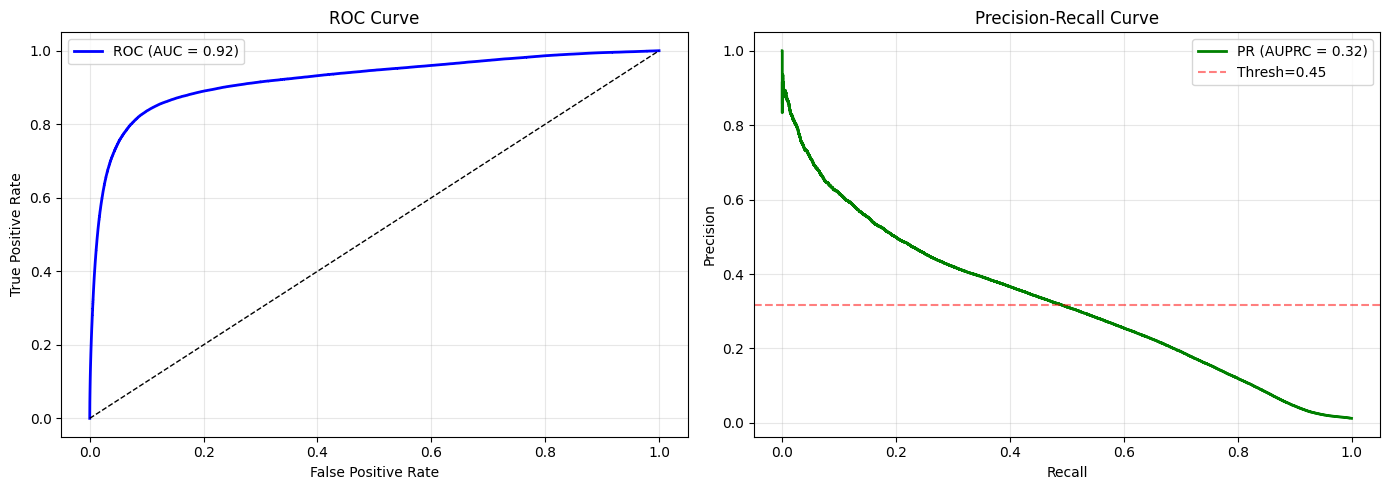

In [13]:
# ============================================
# THRESHOLD SELECTION ON VALIDATION SET (NO DATA LEAKAGE)
# ============================================

def find_optimal_threshold(model, val_loader, device):
    """Find optimal threshold on VALIDATION set to avoid data leakage."""
    model.eval()
    
    all_probs = []
    all_targets = []
    
    print("Finding optimal threshold on VALIDATION set...")
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            y_bin = (y > 0.0).float()
            
            all_probs.extend(probs.cpu().numpy().flatten())
            all_targets.extend(y_bin.cpu().numpy().flatten())
    
    y_true = np.array(all_targets)
    y_prob = np.array(all_probs)
    
    from sklearn.metrics import f1_score
    
    thresholds = np.arange(0.2, 0.7, 0.05)
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in thresholds:
        y_pred_t = (y_prob > thresh).astype(float)
        f1_t = f1_score(y_true, y_pred_t, zero_division=0)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_thresh = thresh
    
    print(f"✓ Optimal threshold on validation set: {best_thresh:.2f} (F1={best_f1:.3f})")
    return best_thresh


# ============================================
# FINAL TEST SET EVALUATION (USING VAL-SET THRESHOLD)
# ============================================

def evaluate_on_test_set(model, test_loader, device, threshold):
    """Proper evaluation with FIXED threshold from validation set."""
    model.eval()
    
    all_probs = []
    all_targets = []
    baseline_preds = []
    
    print(f"\nEvaluating on TEST SET with threshold={threshold:.2f}...")
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            y_bin = (y > 0.0).float()
            
            all_probs.extend(probs.cpu().numpy().flatten())
            all_targets.extend(y_bin.cpu().numpy().flatten())
            
            # Persistence baseline (PrevFireMask is channel 11)
            prev_fire = x[:, 11:12, :, :]
            baseline_preds.extend((prev_fire > 0.0).float().cpu().numpy().flatten())
    
    y_true = np.array(all_targets)
    y_prob = np.array(all_probs)
    y_base = np.array(baseline_preds)
    
    from sklearn.metrics import (confusion_matrix, roc_auc_score, 
                                 average_precision_score, jaccard_score,
                                 precision_recall_fscore_support, roc_curve, 
                                 precision_recall_curve)
    
    # Use FIXED threshold from validation set
    y_pred = (y_prob > threshold).astype(float)
    
    # Core metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    iou = jaccard_score(y_true, y_pred, zero_division=0)
    auprc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    # Baseline metrics
    b_iou = jaccard_score(y_true, y_base, zero_division=0)
    b_prec, b_rec, b_f1, _ = precision_recall_fscore_support(y_true, y_base, average='binary', zero_division=0)
    
    # Also compute at default 0.5 threshold for comparison
    y_pred_05 = (y_prob > 0.5).astype(float)
    _, _, f1_05, _ = precision_recall_fscore_support(y_true, y_pred_05, average='binary', zero_division=0)
    iou_05 = jaccard_score(y_true, y_pred_05, zero_division=0)
    
    # Print Results
    print("\n" + "="*70)
    print(" FINAL TEST SET RESULTS (For Paper Table 1)")
    print("="*70)
    print(f"{'Model':<28} | {'IoU':>6} | {'Recall':>7} | {'Prec':>6} | {'F1':>6} | {'AUPRC':>6}")
    print("-"*70)
    print(f"{'Persistence Baseline':<28} | {b_iou:>6.3f} | {b_rec:>7.3f} | {b_prec:>6.3f} | {b_f1:>6.3f} | {'---':>6}")
    print(f"{'Ours (thresh=0.5)':<28} | {iou_05:>6.3f} | {'---':>7} | {'---':>6} | {f1_05:>6.3f} | {'---':>6}")
    print(f"{'Ours (thresh={threshold:.2f})':<28} | {iou:>6.3f} | {recall:>7.3f} | {precision:>6.3f} | {f1:>6.3f} | {auprc:>6.3f}")
    print("="*70)
    print(f"\nROC-AUC: {roc_auc:.3f}")
    print(f"Test samples: {len(y_true):,} pixels from {len(test_loader.dataset)} tiles")
    
    # Plot curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    axes[0].plot([0,1], [0,1], 'k--', lw=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # PR Curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
    axes[1].plot(rec_curve, prec_curve, 'g-', lw=2, label=f'PR (AUPRC = {auprc:.2f})')
    axes[1].axhline(y=precision, color='r', linestyle='--', alpha=0.5, label=f'Thresh={threshold:.2f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'iou': iou, 'recall': recall, 'precision': precision, 
        'f1': f1, 'auprc': auprc, 'roc_auc': roc_auc,
        'threshold': threshold
    }

# RUN EVALUATION (PROPER WORKFLOW)
print("="*70)
print(" PROPER EVALUATION WORKFLOW (NO DATA LEAKAGE)")
print("="*70)

# Step 1: Find threshold on validation set
optimal_threshold = find_optimal_threshold(model, val_loader, device)

# Step 2: Evaluate on test set with that fixed threshold
results = evaluate_on_test_set(model, test_loader, device, optimal_threshold)

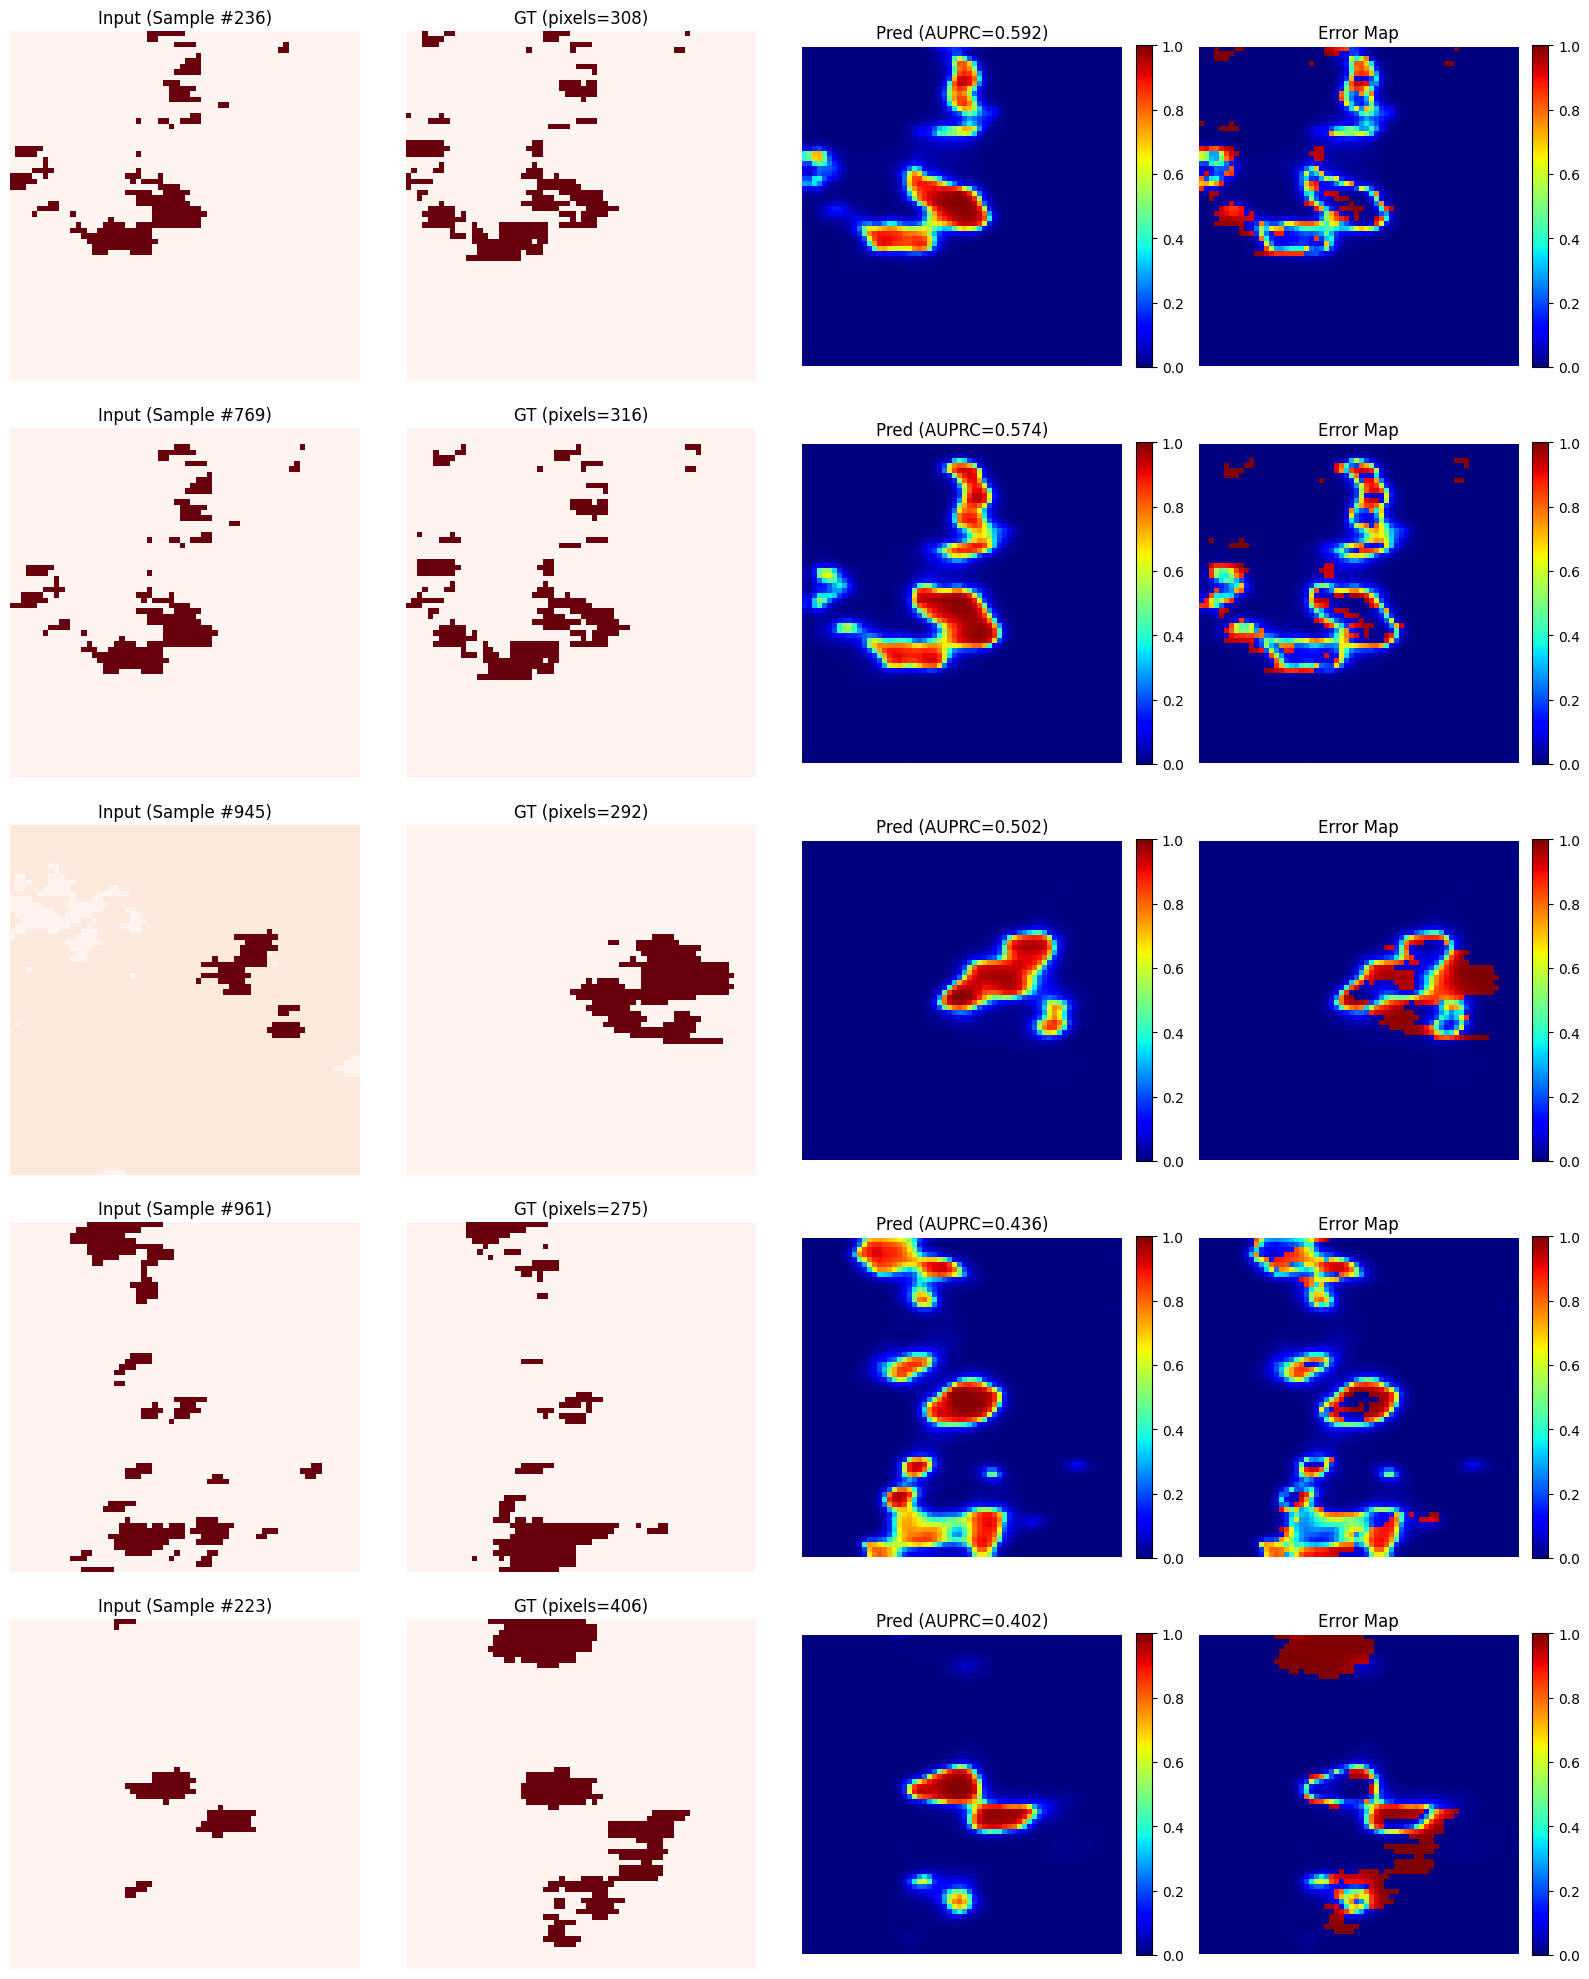

In [44]:
import numpy as np
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import hashlib

def get_sample_id(tensor):
    arr = tensor.detach().cpu().numpy()
    return hashlib.md5(arr.tobytes()).hexdigest()


def visualize_top_k_fire_samples_unique(model, loader, device, k=5, min_fire_pixels=100):
    model.eval()

    results = []
    seen_ids = set()
    global_idx = 0

    # ---------------- COLLECT ----------------
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            y = (y > 0).float()

            logits = model(x)
            probs = torch.sigmoid(logits)

            B = x.shape[0]

            for i in range(B):
                target = y[i, 0]

                # UNIQUE CHECK
                sample_id = get_sample_id(target)
                if sample_id in seen_ids:
                    global_idx += 1
                    continue
                seen_ids.add(sample_id)

                fire_pixels = target.sum().item()

                # FILTER
                if fire_pixels < min_fire_pixels:
                    global_idx += 1
                    continue

                pred = probs[i, 0].detach().cpu().numpy()
                tgt = target.detach().cpu().numpy()

                pred_flat = pred.reshape(-1)
                target_flat = tgt.reshape(-1)

                auprc = average_precision_score(target_flat, pred_flat)

                results.append({
                    "idx": global_idx,
                    "auprc": auprc,
                    "fire_pixels": fire_pixels,
                    "input": x[i, 11].detach().cpu().numpy(),
                    "target": tgt,
                    "pred": pred
                })

                global_idx += 1

    if len(results) == 0:
        print("⚠️ No valid UNIQUE samples found")
        return

    # SORT
    results = sorted(results, key=lambda x: x["auprc"], reverse=True)
    top_k = results[:k]

    # ---------------- VISUALIZE ----------------
    fig, axes = plt.subplots(k, 4, figsize=(16, 4 * k))  # 🔥 4 columns now

    for i, sample in enumerate(top_k):
        input_fire = sample["input"]
        target_fire = sample["target"]
        predicted_fire = sample["pred"]
        auprc = sample["auprc"]
        fire_pixels = sample["fire_pixels"]
        idx = sample["idx"]

        # -------- INPUT --------
        axes[i, 0].imshow(input_fire, cmap='Reds', vmin=0, vmax=1)
        axes[i, 0].set_title(f"Input (Sample #{idx})")
        axes[i, 0].axis('off')

        # -------- GT --------
        axes[i, 1].imshow(target_fire, cmap='Reds', vmin=0, vmax=1)
        axes[i, 1].set_title(f"GT (pixels={int(fire_pixels)})")
        axes[i, 1].axis('off')

        # -------- PREDICTION (UNCHANGED) --------
        im_pred = axes[i, 2].imshow(predicted_fire, cmap='jet', vmin=0, vmax=1)
        axes[i, 2].set_title(f"Pred (AUPRC={auprc:.3f})")
        axes[i, 2].axis('off')
        plt.colorbar(im_pred, ax=axes[i, 2], fraction=0.046, pad=0.04)

        # -------- ERROR MAP (NEW) --------
        error_map = np.abs(predicted_fire - target_fire)

        im_err = axes[i, 3].imshow(error_map, cmap='jet', vmin=0, vmax=1)  # same scheme
        axes[i, 3].set_title("Error Map")
        axes[i, 3].axis('off')
        plt.colorbar(im_err, ax=axes[i, 3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig("top_unique_fire_samples_with_error.png", dpi=150, bbox_inches='tight')
    plt.show()


# RUN
visualize_top_k_fire_samples_unique(
    model,
    test_loader,
    device,
    k=5,
    min_fire_pixels=270
)

In [45]:
import shutil

shutil.make_archive('/kaggle/working/output', 'zip', '/kaggle/working')

'/kaggle/working/output.zip'